# **Overconfidence of Q-learning agents in noisy signals in a voting environment**

**Modifications:**

1.  **`qi` revealed**: the agent has direct access to its actual precision `qi`.
2.  **Overconfidence Penalty**: if the agent votes and is wrong while having chosen `λ_O` (overconfidence), it receives a negative reward `-κ`.

### 1. Package Imports

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(1234)

### 2. Model Parameters

In [ ]:

m = 10
Q_VALUES = np.linspace(0.1, 0.9, m)   # state space: possible q_i values
KAPPA = 0.5  # penalty

# Actions : choose lambda

LAMBDA_O = 1.3   # overconfident  : pi(qi) = 1.3 * qi  (inflates confidence)
LAMBDA_N = 1.0   # neutral        : pi(qi) = qi         (perfect calibration)
LAMBDA_U = 0.7   # underconfident : pi(qi) = 0.7 * qi   (underestimates competence)
LAMBDAS  = [LAMBDA_O, LAMBDA_N, LAMBDA_U]
LAMBDA_NAMES = ['Overconfident (λ=1.3)', 'Neutral (λ=1.0)', 'Underconfident (λ=0.7)']

state_space  = m          # number of possible states (qi values)
action_space = len(LAMBDAS)  # 3 actions

# Q-learning hyperparameters
alpha   = 0.15    # learning rate (same as Calvano notebook)
delta   = 0.95    # discount factor
beta    = 4e-6    # exploration decay rate (epsilon-greedy)

# Simulation
n_episodes      = 5        # number of independent episodes
criterion_final = 500000   # number of periods per episode

print(f"State space  : {state_space} qi values between {Q_VALUES[0]:.2f} and {Q_VALUES[-1]:.2f}")
print(f"Action space: {action_space} lambdas → {LAMBDAS}")
print(f"Q-table size  : {state_space} x {action_space}")

State space  : 10 qi values between 0.10 and 0.90
Action space: 3 lambdas → [1.3, 1.0, 0.7]
Q-table size  : 10 x 3


### 3. Model Functions

In [ ]:

def get_signal(qi, true_state):
    """
    The agent receives a signal si that is correct with probability qi.
    - qi = actual signal precision
    - true_state ∈ {0=A, 1=B} : state of the world
    Returns the observed signal (0 or 1).
    """
    if random.random() < qi:
        return true_state          # correct signal
    else:
        return 1 - true_state      # fake news: inverted signal


def decide_vote(pi_qi):
    """
    Voting rule from Kartal and Tyran:
    The agent votes for its signal if pi(qi) > threshold (here 0.5, cutoff strategy).
    If pi(qi) <= 0.5, it abstains (it considers its signal uninformative).
    Returns True if the agent votes, False if it abstains.
    """
    return pi_qi > 0.5


def compute_reward_with_penalty(signal, lam, qi, true_state, kappa=KAPPA):
    """
    Reward with overconfidence penalty:
    - +1 if correct vote
    - 0  if abstention
    - -kappa if incorrect vote AND λ = λ_O (overconfidence punished)
    - 0  if incorrect vote AND λ ≠ λ_O

    """
    pi_qi = min(lam * qi, 1.0)
    votes = decide_vote(pi_qi)

    if not votes:
        return 0.0  # abstention

    correct_vote = (signal == true_state)
    if correct_vote:
        return 1.0
    else:
        # Penalty if overconfident
        if abs(lam - LAMBDA_O) < 1e-9:  # λ = λ_O
            return -kappa
        else:
            return 0.0


def state_to_index(qi):
    """Converts a qi value to an index in the discrete state space."""
    return np.argmin(np.abs(Q_VALUES - qi))


print("Model functions defined.")
print(f"Example: qi=0.7, λ=1.3 → pi(qi)={1.3*0.7:.3f} → vote={'Yes' if decide_vote(1.3*0.7) else 'No'}")
print(f"Example: qi=0.5, λ=0.7 → pi(qi)={0.7*0.5:.3f} → vote={'Yes' if decide_vote(0.7*0.5) else 'No'}")

Model functions defined.
Example: qi=0.7, λ=1.3 → pi(qi)=0.910 → vote=Yes
Example: qi=0.5, λ=0.7 → pi(qi)=0.350 → vote=No


### 4. Q-learning Algorithm with Revealed qi

**Architecture:**

At each period `t`:
1. The agent observes its actual precision `qi`.
2. **Q-table**: given `qi` (discretized), chooses `λ`.
3. Votes, receives reward (with penalty if overconfident and wrong).
4. Updates Q-table via Bellman.

In [ ]:
def q_learning_voter(beta=4e-6, alpha=0.15, delta=0.95,
                     n_episodes=5, criterion_final=500000):

    # Single Q-table: Q[qi_idx, lambda_idx] learns to choose lambda given actual qi
    q_table = np.zeros((m, action_space))

    # Store results
    lambda_info = np.zeros((criterion_final, n_episodes), dtype=int)
    pi_info = np.zeros((criterion_final, n_episodes))
    reward_info = np.zeros((criterion_final, n_episodes))
    state_info = np.zeros((criterion_final, n_episodes), dtype=int)
    signal_info = np.zeros((criterion_final, n_episodes), dtype=int)

    for ep in range(n_episodes):
        print(f"  Episode {ep+1}/{n_episodes}...")
        # Initialize Q-table for each episode
        q_ep = np.zeros((m, action_space))

        # Initial true qi (state for the environment)
        true_qi_idx = random.randint(0, state_space - 1)

        for t in range(criterion_final):
            epsilon = math.exp(-beta * t)

            # Agent observes true qi directly (state)
            current_qi_idx = true_qi_idx
            true_qi = Q_VALUES[current_qi_idx]
            true_state_world = random.randint(0, 1) # true state of the world (A or B)
            observed_signal = get_signal(true_qi, true_state_world) # si ∈ {0, 1} (still needed for reward calculation)

            # Agent chooses lambda_idx based on current_qi_idx (Q-table state)
            if random.random() <= epsilon:
                lambda_action = random.randint(0, action_space - 1) # exploration
            else:
                lambda_action = np.argmax(q_ep[current_qi_idx]) # exploitation

            chosen_lambda = LAMBDAS[lambda_action]

            # Environment interaction & Reward calculation
            # Reward is calculated based on the TRUE qi, chosen lambda, and signal
            reward = compute_reward_with_penalty(observed_signal, chosen_lambda, true_qi, true_state_world)
            pi_qi = min(chosen_lambda * true_qi, 1.0)

            # Store results
            lambda_info[t, ep] = lambda_action
            pi_info[t, ep]     = pi_qi
            reward_info[t, ep] = reward
            state_info[t, ep]  = current_qi_idx
            signal_info[t, ep] = observed_signal

            # Transition : new qi drawn randomly (different agents)
            # We stay on the same qi with prob 0.8, change otherwise
            # (simulates persistence of an agent's competence)

            if random.random() < 0.8:
                next_qi_idx = current_qi_idx
            else:
                next_qi_idx = random.randint(0, state_space - 1)

            # Q-table update (Bellman equation)
            q_ep[current_qi_idx, lambda_action] = (
                (1 - alpha) * q_ep[current_qi_idx, lambda_action]
                + alpha * (reward + delta * np.max(q_ep[next_qi_idx]))
            )

            true_qi_idx = next_qi_idx # Update the true state for the next period

    print("\nSimulation finished.")
    return lambda_info, pi_info, reward_info, state_info, signal_info

### 5. Launch simulation

In [ ]:
print("Launch simulation...")
print(f"Parameters : alpha={alpha}, beta={beta}, delta={delta}, kappa={KAPPA}")
print(f"             {n_episodes} episodes x {criterion_final} periods\n")

lambda_info, pi_info, reward_info, state_info, signal_info = q_learning_voter(
    beta=beta,
    alpha=alpha,
    delta=delta,
    n_episodes=n_episodes,
    criterion_final=criterion_final
)

Launch simulation...
Parameters : alpha=0.15, beta=4e-06, delta=0.95, kappa=0.5
             5 episodes x 500000 periods

  Episode 1/5...
  Episode 2/5...
  Episode 3/5...
  Episode 4/5...
  Episode 5/5...

Simulation finished.


### 6. Visualizing results

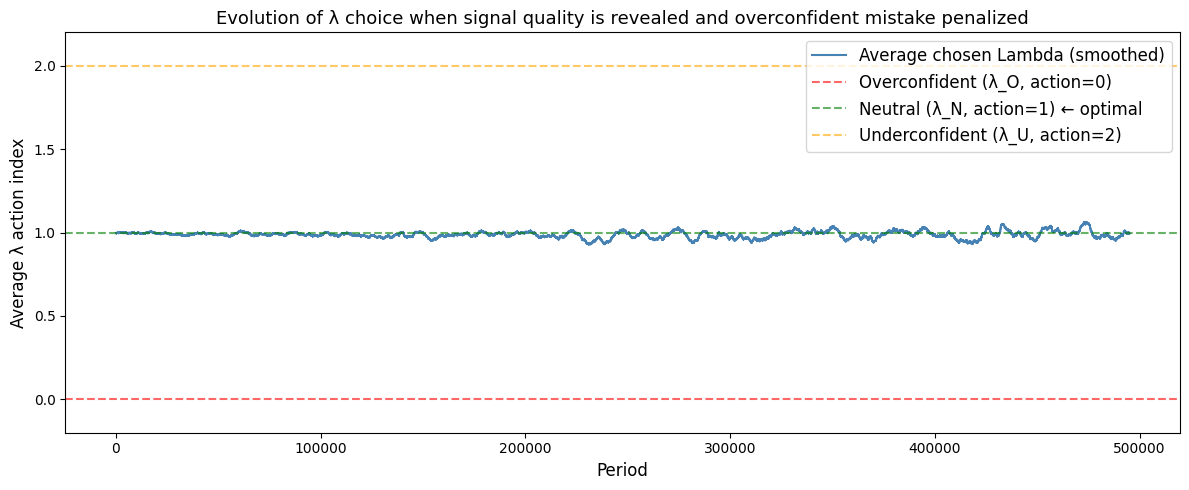

Final average Lambda : 0.98424
  0 = Overconfident | 1 = Neutral | 2 = Underconfident


In [ ]:

# Figure 1 : Evolution of chosen lambda over time

smooth = 5000
avg_lambda = np.mean(lambda_info, axis=1)
smoothed   = np.convolve(avg_lambda, np.ones(smooth)/smooth, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smoothed, color='steelblue', lw=1.5, label='Average chosen Lambda (smoothed)')
ax.axhline(y=0, ls='--', color='red',   alpha=0.6, label='Overconfident (λ_O, action=0)')
ax.axhline(y=1, ls='--', color='green', alpha=0.6, label='Neutral (λ_N, action=1) ← optimal')
ax.axhline(y=2, ls='--', color='orange',alpha=0.6, label='Underconfident (λ_U, action=2)')
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average λ action index', fontsize=12)
ax.set_title('Evolution of λ choice when signal quality is revealed and overconfident mistake penalized', fontsize=13)
ax.legend(fontsize=12)
ax.set_ylim(-0.2, 2.2)
plt.tight_layout()
plt.show()
print("Final average Lambda :", np.mean(lambda_info[-10000:]))
print("  0 = Overconfident | 1 = Neutral | 2 = Underconfident")

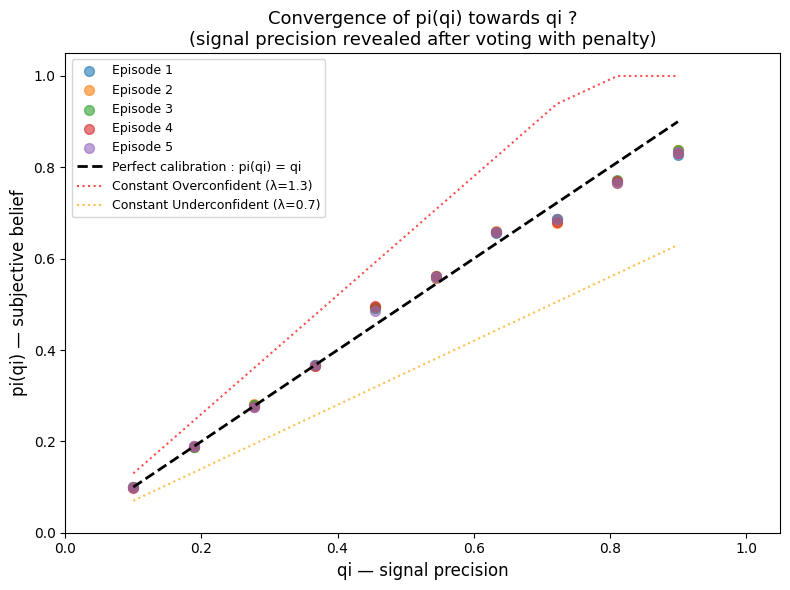

In [ ]:

# Figure 2 : Convergence of subjective belief, does pi(qi) → qi ?

# Average value of pi(qi) per qi state, over the last half of periods
T_half = criterion_final // 2
qi_line     = Q_VALUES   # perfect neutrality, pi(qi) = qi

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate average pi(qi) for each qi (state) for the last half of the simulation
avg_pi_qi_per_state = np.zeros((state_space, n_episodes))
for ep in range(n_episodes):
    for s_idx in range(state_space): # Iterate through each qi (state index)
        # Find all periods where the agent was in this state (s_idx) during the last half
        periods_in_this_state = (state_info[T_half:, ep] == s_idx)
        if np.any(periods_in_this_state):
            # Calculate the average pi(qi) for this state and episode
            avg_pi_qi_per_state[s_idx, ep] = np.mean(pi_info[T_half:, ep][periods_in_this_state])
        else:
            avg_pi_qi_per_state[s_idx, ep] = np.nan # If state was not visited in last half

# Plotting the distribution of pi(qi) vs qi
for ep in range(n_episodes):
    ax.scatter(
        Q_VALUES, # x-axis: actual qi values
        avg_pi_qi_per_state[:, ep], # y-axis: average pi(qi) for each qi in this episode
        alpha=0.6, s=50, label=f'Episode {ep+1}'
    )

# Perfect calibration line (benchmark)
ax.plot(qi_line, qi_line, 'k--', lw=2, label='Perfect calibration : pi(qi) = qi')
# Overconfident / underconfident lines
ax.plot(qi_line, np.minimum(LAMBDA_O * qi_line, 1.0), 'r:', lw=1.5, alpha=0.7, label=f'Constant Overconfident (λ={LAMBDA_O})')
ax.plot(qi_line, LAMBDA_U * qi_line, 'orange', ls=':', lw=1.5, alpha=0.7, label=f'Constant Underconfident (λ={LAMBDA_U})')

ax.set_xlabel('qi — signal precision', fontsize=12)
ax.set_ylabel('pi(qi) — subjective belief', fontsize=12)
ax.set_title('Convergence of pi(qi) towards qi ?\n(signal precision revealed after voting with penalty)', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

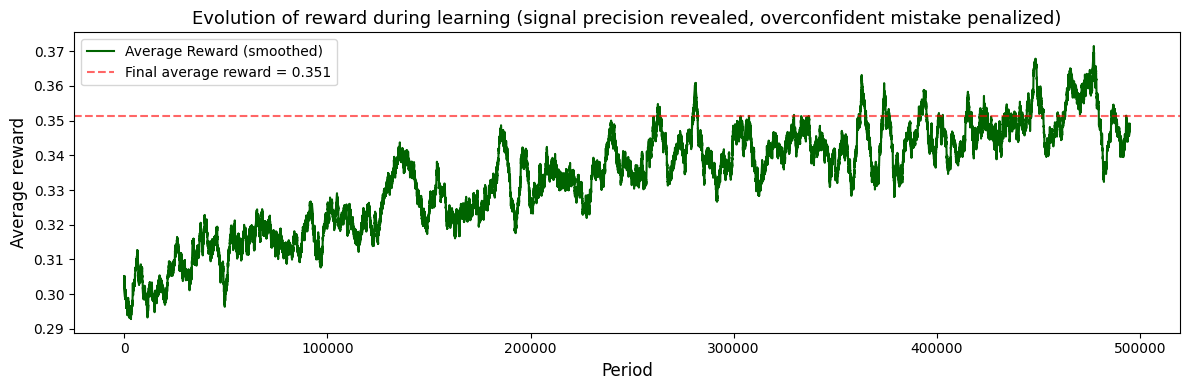

In [ ]:

# Figure 3 : Average reward over time

avg_reward   = np.mean(reward_info, axis=1)
smooth_reward = np.convolve(avg_reward, np.ones(smooth)/smooth, mode='valid')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(smooth_reward, color='darkgreen', lw=1.5, label='Average Reward (smoothed)')
ax.axhline(y=np.mean(avg_reward[-50000:]), ls='--', color='red',
           alpha=0.6, label=f'Final average reward = {np.mean(avg_reward[-50000:]):.3f}')
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average reward', fontsize=12)
ax.set_title('Evolution of reward during learning (signal precision revealed, overconfident mistake penalized)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

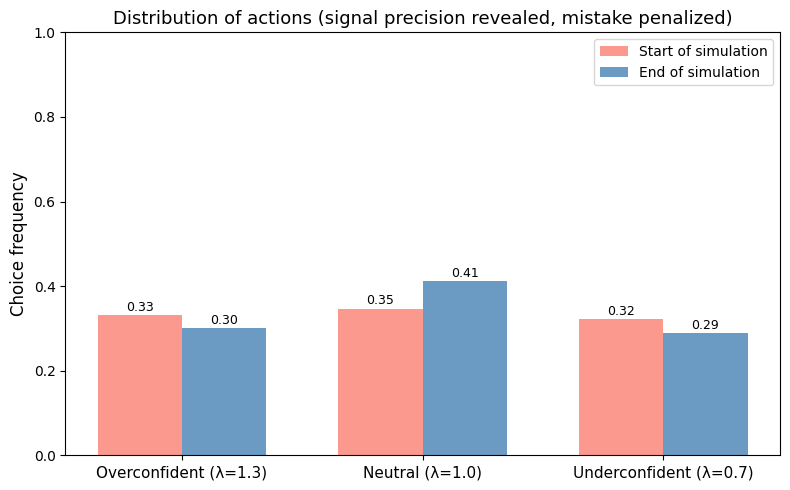

In [ ]:
# Figure 4 : Distribution of chosen actions (start vs end)
T_cut  = criterion_final // 5

debut_counts = np.bincount(lambda_info[:T_cut].flatten(), minlength=3) / (T_cut * n_episodes)
fin_counts   = np.bincount(lambda_info[T_half:].flatten(), minlength=3) / ((criterion_final - T_half) * n_episodes)

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, debut_counts, width, label='Start of simulation', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, fin_counts,   width, label='End of simulation',   color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(LAMBDA_NAMES, fontsize=11)
ax.set_ylabel('Choice frequency', fontsize=12)
ax.set_title('Distribution of actions (signal precision revealed, mistake penalized)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
for bar in bars1: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()